EXP 4 - TRANSFER LEARNING USING PRE-TRAINED VISION MODELS FOR IMAGE RECOGNITION

**Name:** Vibusha G  
**Roll No:** 24BAD128

In [ ]:
# PART A
from google.colab import files

uploaded = files.upload()

Saving archive (7).zip to archive (7).zip


In [ ]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os

for root, dirs, files in os.walk('/content/dataset'):
    if files:
        print(root, "->", len(files), "images")

/content/dataset/train/dogs -> 278 images
/content/dataset/train/cats -> 279 images
/content/dataset/test/dogs -> 70 images
/content/dataset/test/cats -> 70 images


In [ ]:
from sklearn.model_selection import train_test_split
import shutil

cats = []
dogs = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            path = os.path.join(root, file)

            if 'cat' in file.lower():
                cats.append(path)
            elif 'dog' in file.lower():
                dogs.append(path)

cat_train, cat_temp = train_test_split(cats, test_size=0.2, random_state=42)
cat_val, cat_test = train_test_split(cat_temp, test_size=0.5, random_state=42)

dog_train, dog_temp = train_test_split(dogs, test_size=0.2, random_state=42)
dog_val, dog_test = train_test_split(dog_temp, test_size=0.5, random_state=42)

print("Dataset split completed.")
print("Cat:", len(cat_train), len(cat_val), len(cat_test))
print("Dog:", len(dog_train), len(dog_val), len(dog_test))

Dataset split completed.
Cat: 279 35 35
Dog: 278 35 35


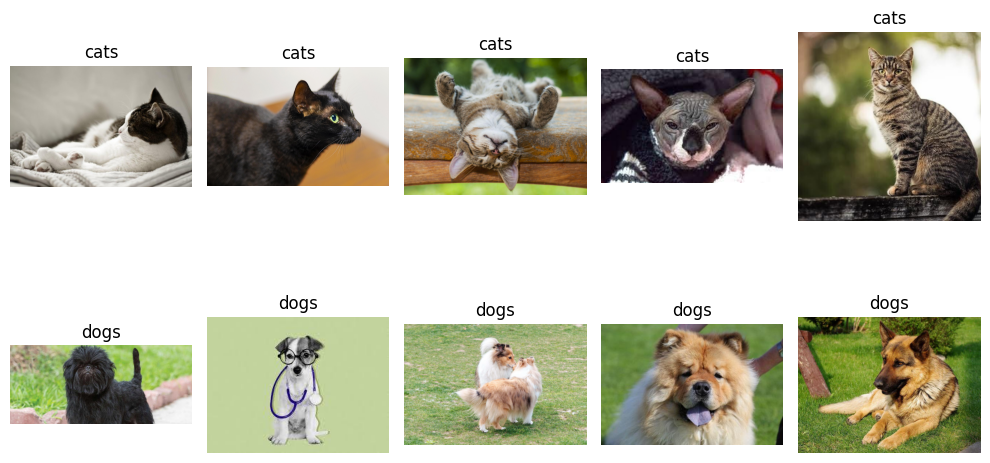

In [ ]:
plt.figure(figsize=(10, 6))

sample_images = []

for category in ['cats', 'dogs']:
    folder = os.path.join(train_dir, category)

    images = [
        f for f in os.listdir(folder)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    for image in images[:5]:
        sample_images.append((os.path.join(folder, image), category))


for i, (image_path, label) in enumerate(sample_images):
    img = plt.imread(image_path)

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 557 images belonging to 2 classes.
Found 70 images belonging to 2 classes.
Found 70 images belonging to 2 classes.


In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 557 images belonging to 2 classes.
Found 70 images belonging to 2 classes.
Found 70 images belonging to 2 classes.


In [ ]:
print("Class indices:")
print(train_generator.class_indices)

print("\nNumber of training images:", train_generator.samples)
print("Number of validation images:", validation_generator.samples)
print("Number of testing images:", test_generator.samples)

Class indices:
{'cats': 0, 'dogs': 1}

Number of training images: 557
Number of validation images: 70
Number of testing images: 70


In [ ]:
# PART B
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

In [ ]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

In [ ]:
base_model.trainable = False

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)

output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# PART C
EPOCHS = 5

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS
)

Epoch 1/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 117s 6s/step - accuracy: 0.7612 - loss: 0.4940 - val_accuracy: 0.9286 - val_loss: 0.2514
Epoch 2/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 106s 6s/step - accuracy: 0.9246 - loss: 0.2595 - val_accuracy: 0.9857 - val_loss: 0.1200
Epoch 3/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 106s 6s/step - accuracy: 0.9623 - loss: 0.1632 - val_accuracy: 0.9857 - val_loss: 0.0773
Epoch 4/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 106s 6s/step - accuracy: 0.9605 - loss: 0.1288 - val_accuracy: 1.0000 - val_loss: 0.0582
Epoch 5/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 141s 6s/step - accuracy: 0.9803 - loss: 0.0968 - val_accuracy: 1.0000 - val_loss: 0.0438


In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.9571 - loss: 0.0975
Test Loss: 0.09745864570140839
Test Accuracy: 0.9571428298950195


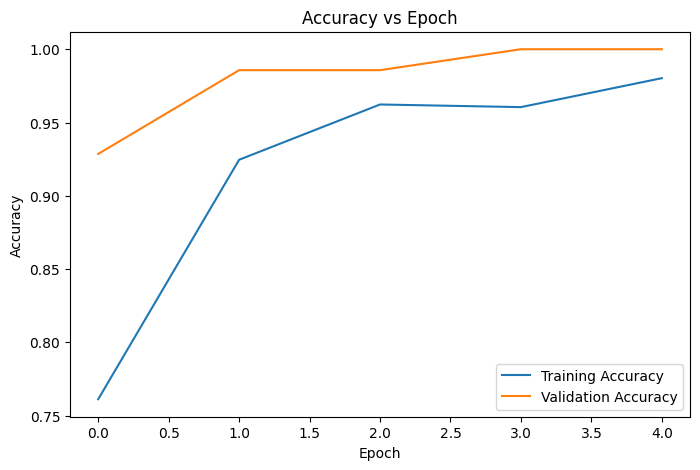

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epoch')
plt.legend()
plt.show()

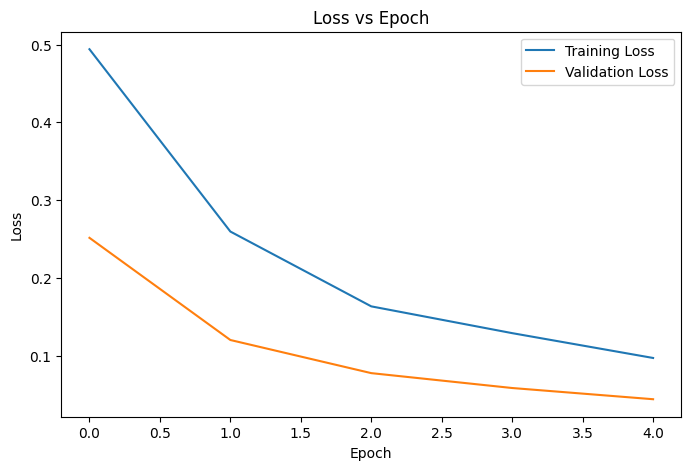

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.show()

In [ ]:
# PART D
!pip install -q transformers

In [ ]:
from transformers import pipeline
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
hf_model = pipeline(
    "image-classification",
    model="google/vit-base-patch16-224"
)

print("Hugging Face model loaded successfully!")

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Hugging Face model loaded successfully!


In [ ]:
import os

sample_image_path = None

for category in ['cats', 'dogs']:
    folder = os.path.join(test_dir, category)
    images = [
        f for f in os.listdir(folder)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    if images:
        sample_image_path = os.path.join(folder, images[0])
        actual_class = category
        break

print("Actual Class:", actual_class)
print("Image:", sample_image_path)

Actual Class: cats
Image: /content/animal_dataset/test/cats/cat_244.jpg


In [ ]:
image = Image.open(sample_image_path).convert("RGB")

hf_result = hf_model(image)

print("Hugging Face Prediction:")
for result in hf_result[:5]:
    print(result)

Hugging Face Prediction:
{'label': 'Egyptian cat', 'score': 0.2745908498764038}
{'label': 'tiger cat', 'score': 0.16651616990566254}
{'label': 'tabby, tabby cat', 'score': 0.08736027032136917}
{'label': 'tobacco shop, tobacconist shop, tobacconist', 'score': 0.03583497554063797}
{'label': 'oxygen mask', 'score': 0.02271442674100399}


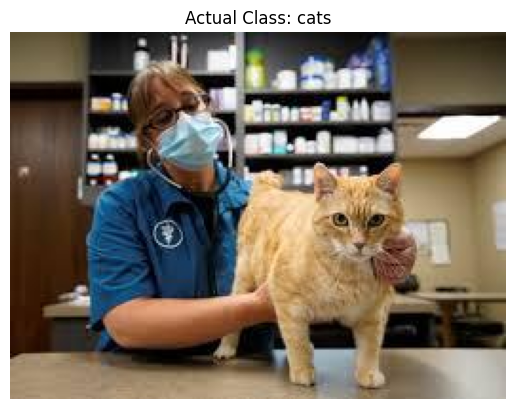

In [ ]:
plt.imshow(image)
plt.title(f"Actual Class: {actual_class}")
plt.axis('off')
plt.show()

In [ ]:
import numpy as np

img = image.resize(IMG_SIZE)
img_array = np.array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)[0][0]

resnet_class = "dog" if prediction >= 0.5 else "cat"

print("Actual Class:", actual_class)
print("ResNet50 Prediction:", resnet_class)
print("ResNet50 Probability:", prediction)
print("Hugging Face Prediction:", hf_result[0]['label'])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Actual Class: cats
ResNet50 Prediction: cat
ResNet50 Probability: 0.3686077
Hugging Face Prediction: Egyptian cat


In [ ]:
print("----- MODEL COMPARISON -----")
print("Actual Class       :", actual_class)
print("ResNet50 Prediction:", resnet_class)
print("Hugging Face       :", hf_result[0]['label'])

----- MODEL COMPARISON -----
Actual Class       : cats
ResNet50 Prediction: cat
Hugging Face       : Egyptian cat


Observations
1. The pre-trained ResNet50 model was successfully used for transfer learning on the Cats and Dogs image dataset.
2. The original classification layer of ResNet50 was replaced with a new classification layer suitable for the two classes: Cat and Dog.
3. Freezing the pre-trained layers allowed the model to reuse the features learned from the ImageNet dataset.
4. The model achieved a test accuracy of 95.71% in the initial experiment.
5. The Hugging Face pre-trained vision model was able to classify the sample images without training the model from scratch.
6. The Hugging Face model produced ImageNet-based labels, while the ResNet50 model was specifically trained to distinguish between cats and dogs.
7. Transfer learning reduced the need for extensive training and computational resources compared with developing a CNN completely from scratch.
8. The experiment demonstrated that pre-trained vision models can be adapted for real-world image classification tasks.